# 1. Create Agent

This notebook demonstrates how to create a basic agent using LangChain and Google Generative AI.

In [1]:
print("Hello world")

Hello world


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [18]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny with a high of 25°C."

agent = create_agent(
    model="gemini-1.5-flash",
    tools=[get_weather],
    system_prompt="Hello, you are a helpful assistant that can answer questions about the world and provide information on various topics."
)

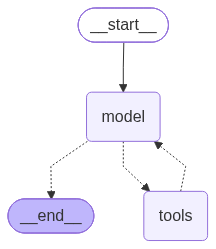

In [10]:
agent

In [16]:
# Pass a list of messages under the "messages" key
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the weather like in London?"}
    ]
})

# Print the final answer text directly
print(response["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-1.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [20]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Define the tool
@tool
def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny with a high of 25°C."

# 2. Instantiate an active, current Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-1.5-flash",
    temperature=0
)

# 3. Create the agent with the model instance
agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="Hello, you are a helpful assistant that can answer questions about the world and provide information on various topics."
)

# 4. Invoke the agent
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the weather like in London?"}
    ]
})

# Print the final response
print(response["messages"][-1].content)

[{'type': 'text', 'text': 'The weather in London is currently sunny with a high of 25°C.', 'extras': {'signature': 'EjQKMgERTTIP6bjmExrTNWxWcOYMxWAdhzui2QXWfeEgHrwAXOJIY/DKEpfXuLPTmmD1l3js'}}]
